# Machine Learning for Read Sensor Value

We will take the data from the simulation that we created.

First Start a Simulator. [Check the readme of the Sensorhub Simulator](sensorhub/README.md)

1. Add a new Sensor, named "Sonar Sensor" [0-4]
2. Add a new Sensor, named "Velocity Sensor" [0-50]


In [24]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Add the libs directory to Python path
current_dir = os.path.dirname(os.path.abspath('KelmanFiltering.ipynb'))
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector
from kelmanfilter import KalmanFilter1D, KalmanFilter2D

dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


## Create Dataset

In [2]:
message_queue = WebSocketCollector(ws_url, max_messages=1000).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 1000


In [10]:
list(message_queue.queue)[1]

'{"type": "data", "data": {"sensor_id": "b4a461f6-7239-42f9-b6b3-5eded4bdd38a", "value": 0.11958411461697924, "actual_value": 0, "timestamp": "2026-06-21T19:21:20.846070"}}'

In [ ]:
initial_data = list(message_queue.queue)[0]
raw_sensors_array = json.loads(initial_data)['data']['sensors']
print("Initial data object:", initial_data)

raw_values_df = {}

for sensor in raw_sensors_array:
    sensor_id = sensor.get('id')
    raw_values_df[sensor_id] = {
        "name": sensor.get('name'),
        "value": [],
        "actual_value": []
    }

print(len(message_queue.queue))
print("Raw values DataFrame:", raw_values_df)

for message in list(message_queue.queue)[1:990]:
    data = json.loads(message)['data']
    sensor_id = data.get('sensor_id')
    if sensor_id in raw_values_df:
        raw_values_df[sensor_id]['value'].append(data.get('value'))
        raw_values_df[sensor_id]['actual_value'].append(data.get('actual_value'))

dataframe = pd.DataFrame(columns=['Distance', 'Velocity', 'Actual_distance', 'Actual_velocity', 'S'])

distance_sensor_id = list(raw_values_df.keys())[0]
velocity_sensor_id = list(raw_values_df.keys())[1]

for i in range(len(raw_values_df[distance_sensor_id]['value'])):
    dataframe.loc[i] = [
        raw_values_df[distance_sensor_id]['value'][i],
        raw_values_df[velocity_sensor_id]['value'][i],
        raw_values_df[distance_sensor_id]['actual_value'][i],
        raw_values_df[velocity_sensor_id]['actual_value'][i],
        i
    ]
print(dataframe.head())

dataframe.to_csv(os.path.join(dataset_dir, 'sensor_data.csv'), index=False)

Initial data object: {"type": "initial_state", "data": {"sensors": [{"id": "2dfcbef4-500c-47cf-98c6-2d830a17c625", "name": "Sonar Sensor", "type": "custom", "interval": 0.1, "min_value": 0, "max_value": 4, "is_running": true, "current_value": 0, "recording": false, "parameters": {"actual_value": 0, "tolerance": 0.5}}, {"id": "b4a461f6-7239-42f9-b6b3-5eded4bdd38a", "name": "Velocity Sensor", "type": "custom", "interval": 0.1, "min_value": 0, "max_value": 10, "is_running": true, "current_value": 0.6974043254353954, "recording": false, "parameters": {"actual_value": 0, "tolerance": 0.5}}], "mqtt_connected": false, "recordings": {}}}
1000
Raw values DataFrame: {'2dfcbef4-500c-47cf-98c6-2d830a17c625': {'name': 'Sonar Sensor', 'value': [], 'actual_value': []}, 'b4a461f6-7239-42f9-b6b3-5eded4bdd38a': {'name': 'Velocity Sensor', 'value': [], 'actual_value': []}}
   Distance  Valocity  actual_distance  actual_velocity    S
0  0.559497  0.119584              0.0              0.0  0.0
1  0.301896

## Load Dataset

In [2]:
data = pd.read_csv(f"{dataset_dir}/sensor_data.csv")

distance_df = data[['Distance', 'Actual_Distance']]
velocity_df = data[['Velocity', 'Actual_Velocity']]

print(data.head())
print(distance_df.head())
print(velocity_df.head())

   Distance  Velocity  Actual_Distance  Actual_Velocity    S
0  0.559497  0.119584              0.0              0.0  0.0
1  0.301896  0.000000              0.0              0.0  1.0
2  0.000000  0.210869              0.0              0.0  2.0
3  0.037240  0.297466              0.0              0.0  3.0
4  0.000000  0.651939              0.0              0.0  4.0
   Distance  Actual_Distance
0  0.559497              0.0
1  0.301896              0.0
2  0.000000              0.0
3  0.037240              0.0
4  0.000000              0.0
   Velocity  Actual_Velocity
0  0.119584              0.0
1  0.000000              0.0
2  0.210869              0.0
3  0.297466              0.0
4  0.651939              0.0


In [3]:
print(data.info())
print(distance_df.info())
print(velocity_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Distance         464 non-null    float64
 1   Velocity         464 non-null    float64
 2   Actual_Distance  464 non-null    float64
 3   Actual_Velocity  464 non-null    float64
 4   S                464 non-null    float64
dtypes: float64(5)
memory usage: 18.3 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Distance         464 non-null    float64
 1   Actual_Distance  464 non-null    float64
dtypes: float64(2)
memory usage: 7.4 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Velocity         464 non-nu

In [4]:
print(data.isnull().sum())
print(distance_df.isnull().sum())
print(velocity_df.isnull().sum())

Distance           0
Velocity           0
Actual_Distance    0
Actual_Velocity    0
S                  0
dtype: int64
Distance           0
Actual_Distance    0
dtype: int64
Velocity           0
Actual_Velocity    0
dtype: int64


In [5]:
print(data.describe())
print(distance_df.describe())
print(velocity_df.describe())

         Distance    Velocity  Actual_Distance  Actual_Velocity           S
count  464.000000  464.000000       464.000000       464.000000  464.000000
mean     0.283028    3.832296         0.112069         3.781034  231.500000
std      0.353003    2.787839         0.176432         2.781291  134.089522
min      0.000000    0.000000         0.000000         0.000000    0.000000
25%      0.000000    1.298032         0.000000         1.300000  115.750000
50%      0.111903    3.566517         0.000000         3.600000  231.500000
75%      0.492994    6.487130         0.200000         6.625000  347.250000
max      1.642398   10.000000         0.600000         9.200000  463.000000
         Distance  Actual_Distance
count  464.000000       464.000000
mean     0.283028         0.112069
std      0.353003         0.176432
min      0.000000         0.000000
25%      0.000000         0.000000
50%      0.111903         0.000000
75%      0.492994         0.200000
max      1.642398         0.600000
 

In [6]:
print(data.duplicated().sum())
print(distance_df.duplicated().sum())
print(velocity_df.duplicated().sum())

data_cleaned_df = data.drop_duplicates()
distance_cleaned_df = distance_df.drop_duplicates()
velocity_cleaned_df = velocity_df.drop_duplicates()

print("Removed ")
print(data_cleaned_df.size)
print(distance_cleaned_df.size)
print(velocity_cleaned_df.size)

0
192
34
Removed 
2320
544
860


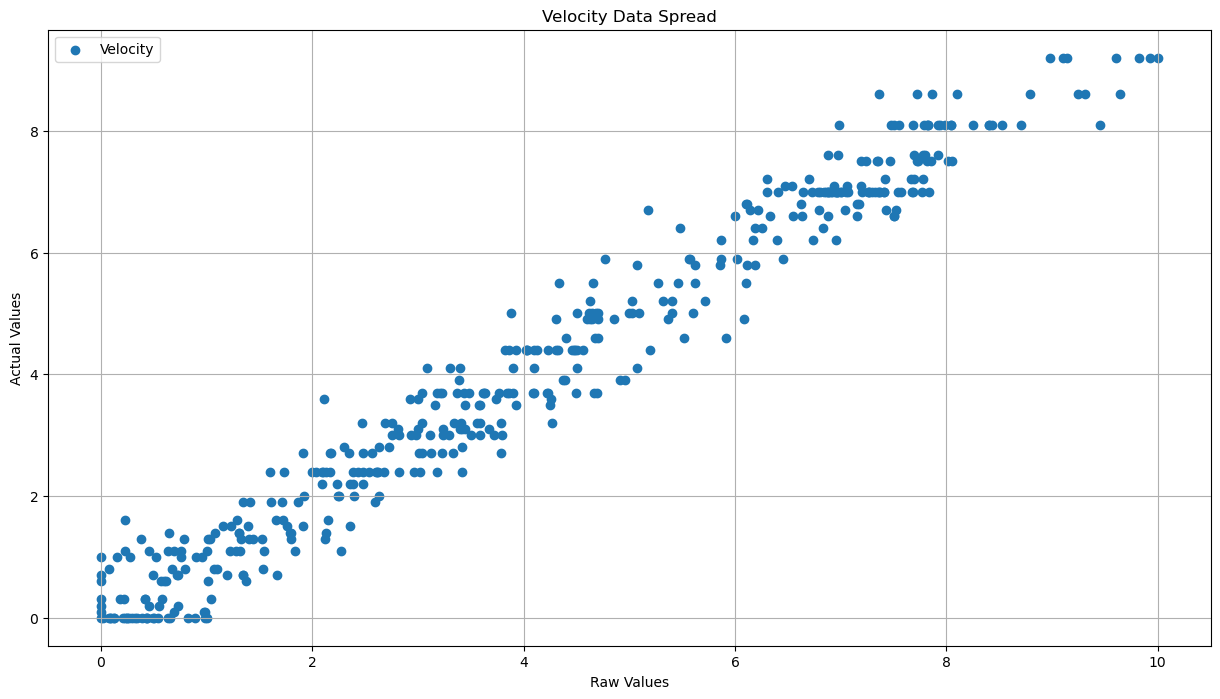

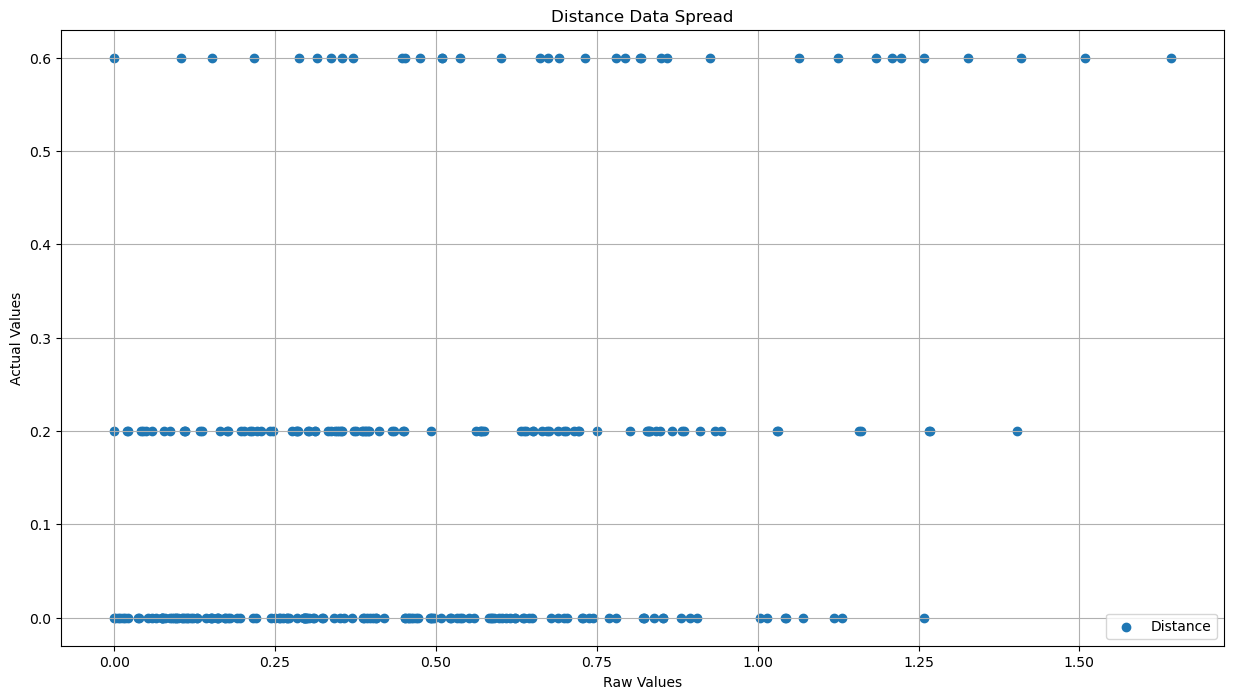

In [7]:
# Visualize the data

plt.figure(figsize=[15,8])
plt.scatter(x = velocity_cleaned_df['Velocity'], y = velocity_cleaned_df['Actual_Velocity'], label = 'Velocity')
plt.title('Velocity Data Spread')
plt.xlabel('Raw Values')
plt.ylabel('Actual Values')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=[15,8])
plt.scatter(x = distance_cleaned_df['Distance'], y = distance_cleaned_df['Actual_Distance'], label = 'Distance')
plt.title('Distance Data Spread')
plt.xlabel('Raw Values')
plt.ylabel('Actual Values')
plt.legend()
plt.grid(True)
plt.show()

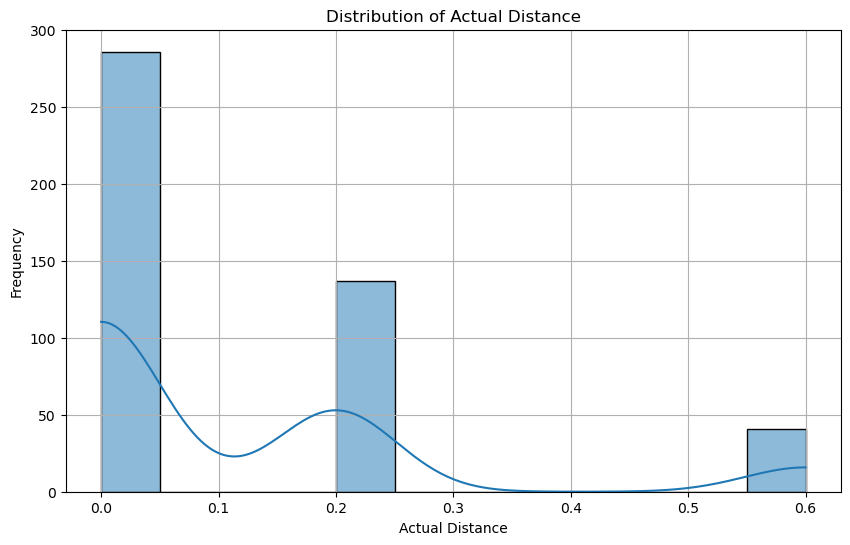

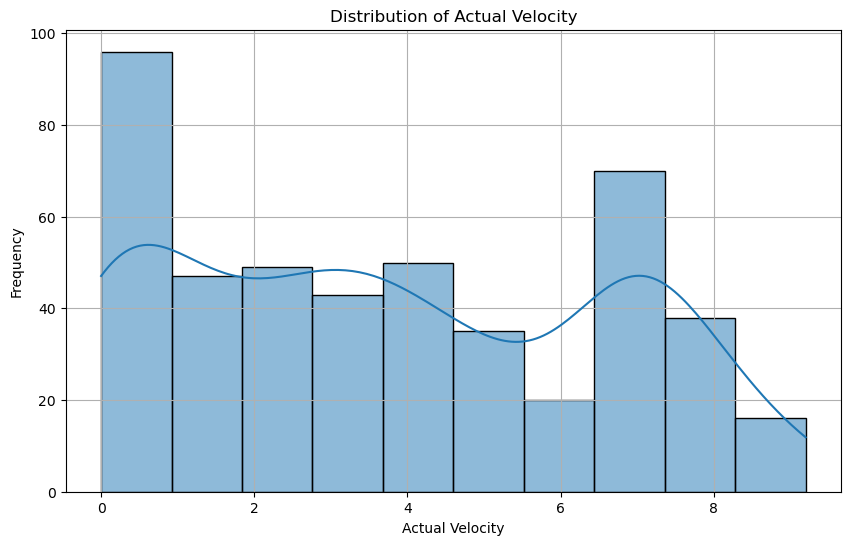

In [8]:
# distribution of the target variable
plt.figure(figsize=[10,6])
sns.histplot(data['Actual_Distance'], kde=True)
plt.title('Distribution of Actual Distance')
plt.xlabel('Actual Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=[10,6])
sns.histplot(data['Actual_Velocity'], kde=True)
plt.title('Distribution of Actual Velocity')
plt.xlabel('Actual Velocity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Frequency')

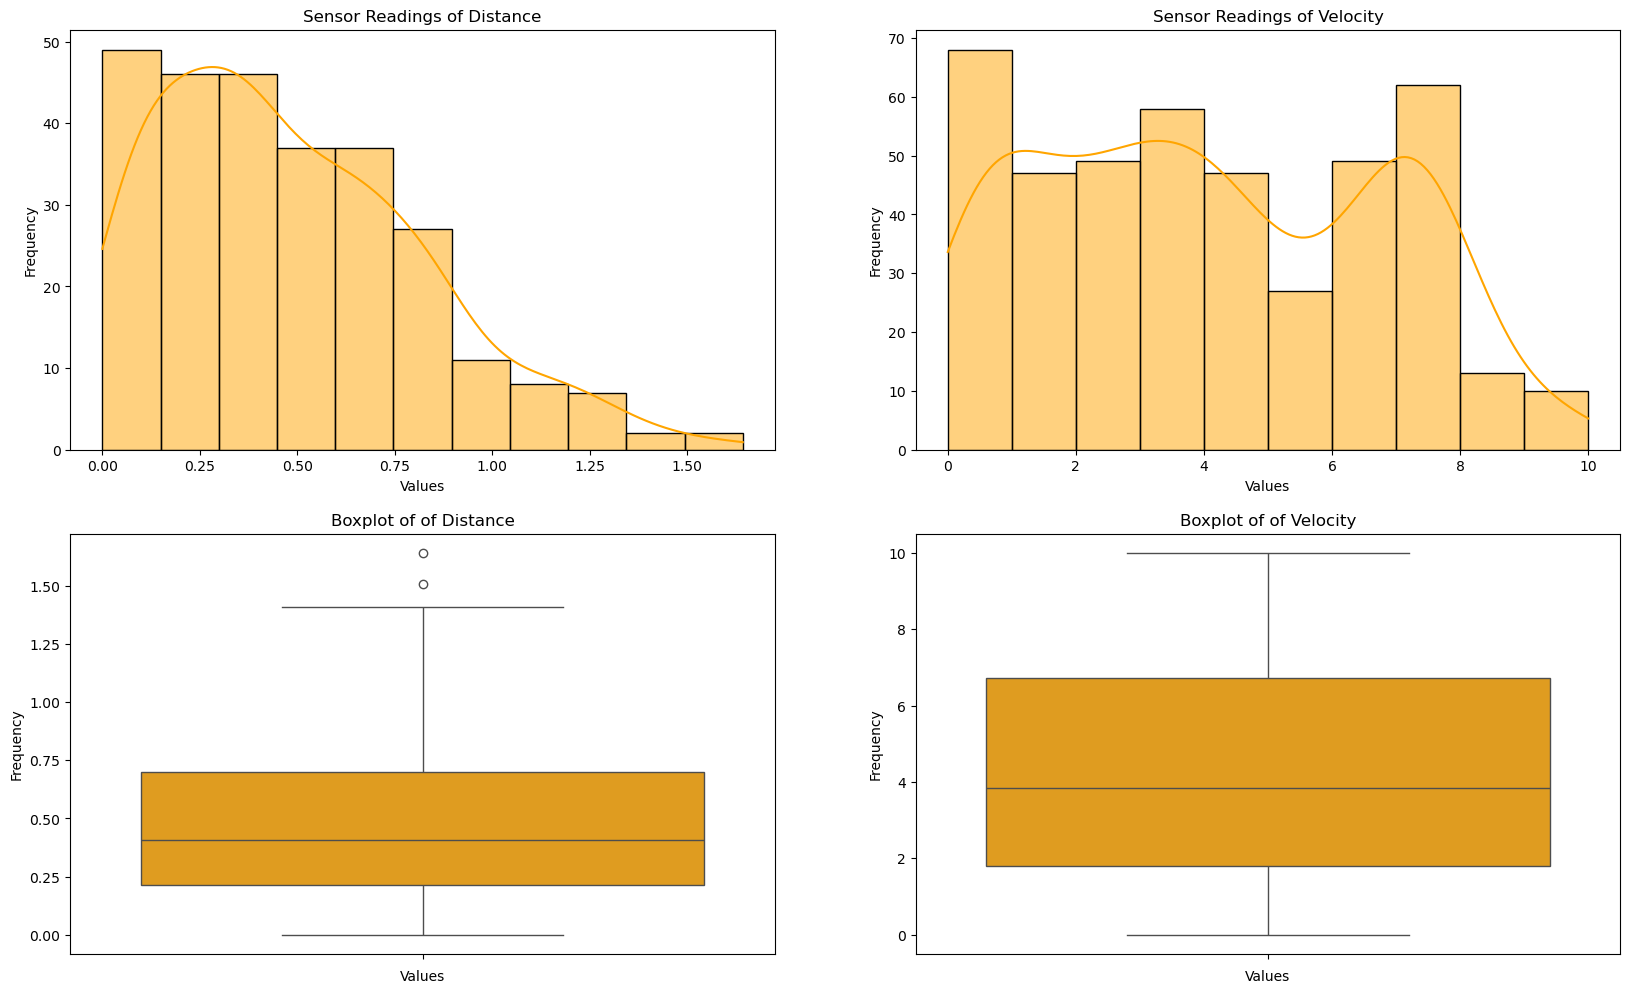

In [9]:
plt.figure(figsize=[20,12])

plt.subplot(2, 2, 1)
sns.histplot(distance_cleaned_df['Distance'], color = 'orange', kde=True)
plt.title(f'Sensor Readings of Distance')
plt.xlabel('Values')
plt.ylabel('Frequency') 

plt.subplot(2, 2, 2)
sns.histplot(velocity_cleaned_df['Velocity'], color = 'orange', kde=True)
plt.title(f'Sensor Readings of Velocity')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.boxplot(distance_cleaned_df['Distance'], color = 'orange')
plt.title(f'Boxplot of of Distance')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.boxplot(velocity_cleaned_df['Velocity'], color = 'orange')
plt.title(f'Boxplot of of Velocity')
plt.xlabel('Values')
plt.ylabel('Frequency')

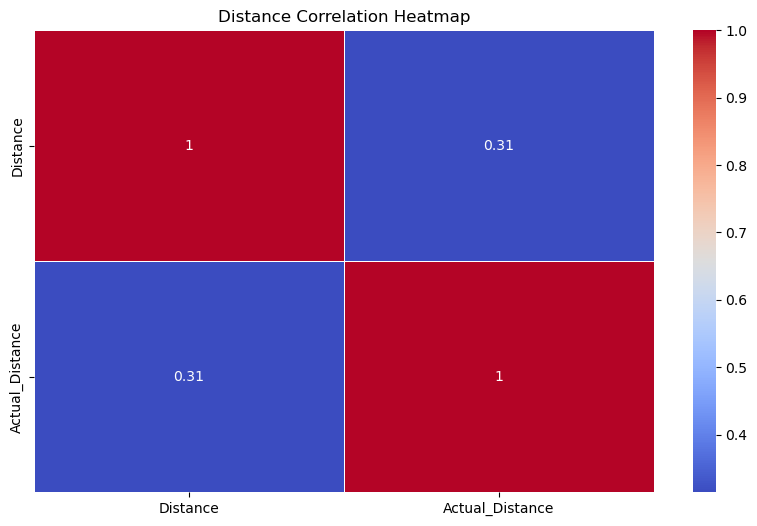

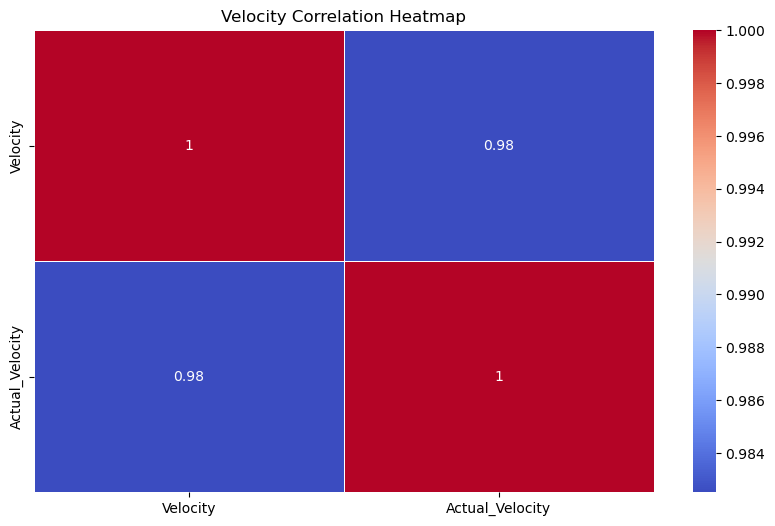

In [10]:
plt.figure(figsize=[10,6])
sns.heatmap(distance_cleaned_df.corr(method='pearson'), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Distance Correlation Heatmap')
plt.show()

plt.figure(figsize=[10,6])
sns.heatmap(velocity_cleaned_df.corr(method='pearson'), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Velocity Correlation Heatmap')
plt.show()

## Build the Model

However, According to the data, only velocity data provides the enough and accurate data for the linear regression model.

In [11]:
X = velocity_cleaned_df['Velocity'].values.reshape(-1, 1)
y = velocity_cleaned_df['Actual_Velocity'].values

X[0], y[0]

(array([0.11958411]), np.float64(0.0))

In [12]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.98]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.02275
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[48.84]


In [14]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [15]:
# Coefficients of the model
print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Slope: 0.9775
Intercept: 0.0227


## Model Evaluation

In [16]:
# R-squared value
r2_train = r2_score(y_train, y_train_pred)
print(f"R-squared for {model.__class__.__name__} Train: {r2_train:.4f}")

r2_test = r2_score(y_test, y_test_pred)
print(f"R-squared for {model.__class__.__name__} Test: {r2_test:.4f}")

# Mean Squared Error
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Mean Squared Error for {model.__class__.__name__} Train: {mse_train:.4f}")

mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error for {model.__class__.__name__} Test: {mse_test:.4f}")

R-squared for LinearRegression Train: 0.9628
R-squared for LinearRegression Test: 0.9736
Mean Squared Error for LinearRegression Train: 0.2557
Mean Squared Error for LinearRegression Test: 0.2112


Text(0, 0.5, 'Actual Values')

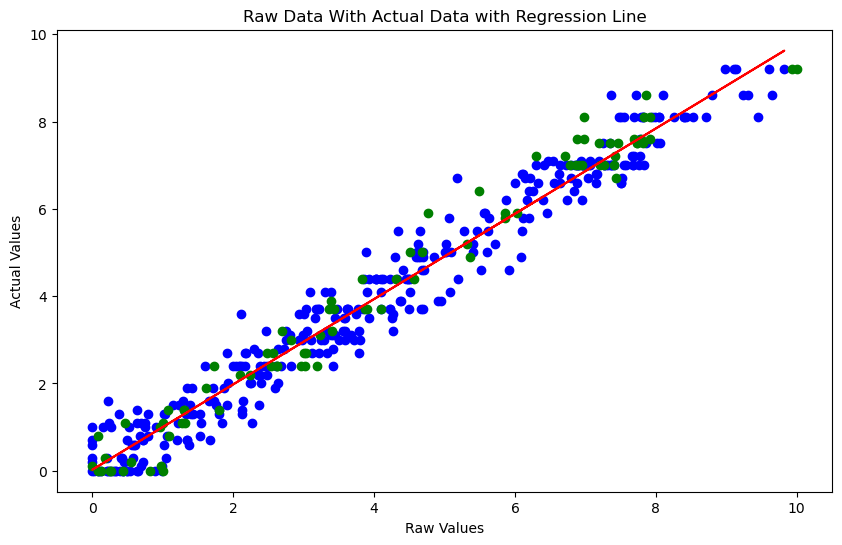

In [17]:
# Visualize the model's predictions
plt.figure(figsize=[10,6])
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Testing Data')
plt.plot(X_train, y_train_pred, color='red', label='Regression Line')
plt.title('Raw Data With Actual Data with Regression Line')
plt.xlabel('Raw Values')
plt.ylabel('Actual Values')

## Work With Real Data

Now we only get velocity data

In [19]:
message_queue = WebSocketCollector(ws_url, max_messages=100).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 100


In [20]:
initial_data = json.loads(list(message_queue.queue)[0]).get('data')
sensor_id = None
for sensor in initial_data.get('sensors'):
    if sensor.get('name') == 'Velocity Sensor':
        sensor_id = sensor.get('id')

print('Sensor Id', sensor_id)

Sensor Id b4a461f6-7239-42f9-b6b3-5eded4bdd38a


In [21]:
sensor_raw_data = np.array([])
actual_value_data = np.array([])

for data in list(message_queue.queue):
    data = json.loads(data)
    if data.get('type') == 'data':
        sensor_raw_data = np.append(sensor_raw_data, [data.get('data').get('value')])
        actual_value_data = np.append(actual_value_data, [data.get('data').get('actual_value')])

predicted_values_data = np.array([])
raw_distance = np.array([])
predicted_distance = np.array([])
actual_distance = np.array([])

raw_vehicle_distance = 0
predicted_vehicle_distance = 0
actual_vehicle_distance = 0

for i in range(len(sensor_raw_data)):

    raw_velocity = sensor_raw_data[i]
    actual_velocity = actual_value_data[i]

    predicted_velocity = model.predict(np.array([raw_velocity]).reshape(-1, 1))
    predicted_values_data=np.append(predicted_values_data, [predicted_velocity])

    predicted_vehicle_distance = predicted_vehicle_distance + predicted_velocity * 0.1
    raw_vehicle_distance = raw_vehicle_distance + raw_velocity * 0.1
    actual_vehicle_distance = actual_vehicle_distance + actual_velocity * 0.1

    raw_distance = np.append(raw_distance, [raw_vehicle_distance])
    predicted_distance = np.append(predicted_distance, [predicted_vehicle_distance])
    actual_distance = np.append(actual_distance, [actual_vehicle_distance])

real_dataframe = pd.DataFrame({
    "Raw Velocity": np.round(sensor_raw_data, decimals=2),
    "Predicted Velocity": np.round(predicted_values_data, decimals=2),
    "Actual Velocity": np.round(actual_value_data, decimals=2),
    "Raw Distance": np.round(raw_distance, decimals=2),
    "Predicted Distance": np.round(predicted_distance, decimals=2),
    "Actual Distance": np.round(actual_distance, decimals=2),
})

real_dataframe.head()


,Raw Velocity,Predicted Velocity,Actual Velocity,Raw Distance,Predicted Distance,Actual Distance
0,1.29,1.28,1.7,0.13,0.13,0.17
1,1.21,1.20,1.7,0.25,0.25,0.34
2,1.51,1.50,1.7,0.40,0.40,0.51
3,1.90,1.88,1.7,0.59,0.59,0.68
4,1.61,1.59,1.7,0.75,0.75,0.85


Text(0, 0.5, 'Distance Values')

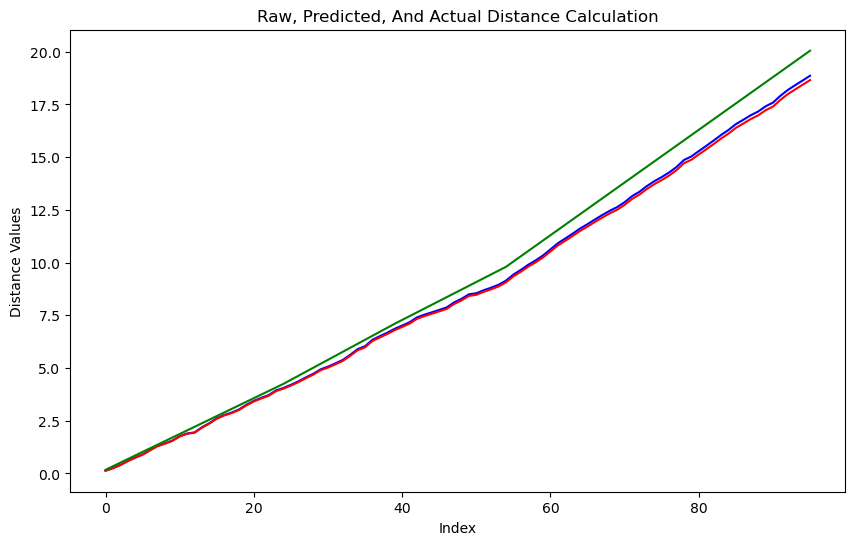

In [22]:
plt.figure(figsize=[10,6])

#plt.plot(range(sensor_raw_data.size), sensor_raw_data, color='blue', linestyle='dashed', label='Raw Sensor Data')
plt.plot(range(raw_distance.size), raw_distance, color='blue', label='Raw Distance Data')

#plt.plot(range(predicted_values_data.size), predicted_values_data, color='red', linestyle='dashed', label='Predicted Sensor Data')
plt.plot(range(predicted_distance.size), predicted_distance, color='red', label='Predicted Distance Data')

#plt.plot(range(actual_value_data.size), actual_value_data, color='green', linestyle='dashed', label='Actual Sensor Data')
plt.plot(range(actual_distance.size), actual_distance, color='green', label='Actual Distance Data')

plt.title('Raw, Predicted, And Actual Distance Calculation')
plt.xlabel('Index')
plt.ylabel('Distance Values')

In [23]:
# R-squared value
r2_train = r2_score(actual_distance, predicted_distance)
print(f"R-squared for {model.__class__.__name__} Actual Test Values: {r2_train:.4f}")

mse_train = mean_squared_error(actual_distance, predicted_distance)
print(f"Mean Squared Error for {model.__class__.__name__} Actual Test Values: {mse_train:.4f}")

R-squared for LinearRegression Actual Test Values: 0.9830
Mean Squared Error for LinearRegression Actual Test Values: 0.5697


### Save the Model for future uses

In [ ]:
with open(f"{models_dir}/regression_model.pkl", 'wb') as file:
    pickle.dump(model, file)